## **Music Recommendation Algorithm Project**
</br>
Info here

***Model***

Details

---
### **1. Imports**

In [1]:
# Importing sys to ensure proper environment setup
import sys

print(sys.version_info)

sys.version_info(major=3, minor=11, micro=14, releaselevel='final', serial=0)


In [2]:
# Importing pandas and numpy for numerical analysis
# Importing pyplot and seaborn to visualize the data
# Importing os, pathlib, and warnings for functionality, faster loading, flagging exceptions, etc.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker, pylab
from matplotlib.legend import Legend
import statistics
from scipy.stats import skew, kurtosis, trim_mean
import seaborn as sns
import lightgbm as lgb
import os # possibly remove
from pathlib import Path, PureWindowsPath
from scipy.stats import multivariate_normal, norm, trim_mean, zscore
import warnings
warnings.filterwarnings('ignore')

# Importing sklearn items for preprocessing, model training & testing
from sklearn.preprocessing import (
    LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, Normalizer)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedGroupKFold
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error, classification_report, silhouette_score,
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier

from kneed import KneeLocator, DataGenerator, find_shape
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# Different label assignment (assign_labels="cluster_qr") as deterministic partitioning alternative
from sklearn.cluster import KMeans, AffinityPropagation, DBSCAN, SpectralClustering
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

# Makes graphs appear in line
%matplotlib inline

sns.set(style="whitegrid", palette="Set3", font_scale=1.25)    # alt muted, spectral, tab20c

print("Setup Complete")

Setup Complete


---
### **2. Load Data & Quick Review**

In [3]:
# Explicitly noting path as being in Windows format to avoid issues with backsplash
#filename = PureWindowsPath("..Data\tcc_ceds_music.csv")

# Convert path to the correct format
#file_path = Path(filename)
rec_test = open("C:\\Users\\winni\\music-rec-algo\\Data\\rec_clean_test.csv")
clean_a = open("C:\\Users\\winni\\music-rec-algo\\Data\\clean_a1.csv")

# Loading data as a DataFrame
df_rec_test = pd.read_csv(rec_test) 
df_clean_a = pd.read_csv(clean_a)

# Using head() function to display the first five rows of the data
print("Heads")
print("Recommendation Test Data:", df_rec_test.head())
print("Cleaned Data:", df_clean_a.head())

Heads
Recommendation Test Data:         artist_name           track_name  release_date    dating  violence  \
0          godsmack               immune      0.859742 -0.418129  0.688735   
1      dennis brown        second chance      0.584184 -0.412965 -0.696636   
2  the black crowes          sister luck      0.418849 -0.414664  1.273356   
3   jerry lee lewis  your cheating heart     -1.234502  2.907046 -0.816073   
4         paul anka             eso beso     -0.903832 -0.413852 -0.821892   

   world_life  night_time  shake_the_audience  family_gospel  romantic  ...  \
0    2.523982   -0.924201            2.958886      -0.507165 -0.389008  ...   
1   -0.790271    1.025128           -0.413514       0.457949  0.038872  ...   
2   -0.791193   -0.922847           -0.415081       2.837519 -0.387686  ...   
3   -0.778914   -0.102406           -0.394226      -0.459734 -0.379055  ...   
4   -0.790752   -0.609398           -0.414333       0.163963  2.976164  ...   

   genre_country  genre_

In [4]:
# Using shape() function to return a tuple listing number of rows and columns in the data

print("Shape of Rec Test:", df_rec_test.shape)
print("Shape of Clean Data:", df_clean_a.shape)

Shape of Rec Test: (10, 29)
Shape of Clean Data: (28372, 29)


In [5]:
# Using info() function to view column names, data types, and other relevant information

df_rec_test.info()

df_clean_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   artist_name               10 non-null     object 
 1   track_name                10 non-null     object 
 2   release_date              10 non-null     float64
 3   dating                    10 non-null     float64
 4   violence                  10 non-null     float64
 5   world_life                10 non-null     float64
 6   night_time                10 non-null     float64
 7   shake_the_audience        10 non-null     float64
 8   family_gospel             10 non-null     float64
 9   romantic                  10 non-null     float64
 10  communication             10 non-null     float64
 11  obscene                   10 non-null     float64
 12  music                     10 non-null     float64
 13  movement_places           10 non-null     float64
 14  light_visual_

In [6]:
# Updating column names to remove whitespace and erroroneous characters on rec_test

df_rec_test.columns = df_rec_test.columns.str.strip().str.replace(' ', '_').str.replace('(', '').str.replace(':', '')
df_rec_test.columns = df_rec_test.columns.str.replace(')', '').str.replace('-', '_').str.replace('/', '_')
print("Updated Column Names:", df_rec_test.columns)
print(df_rec_test.info())

Updated Column Names: Index(['artist_name', 'track_name', 'release_date', 'dating', 'violence',
       'world_life', 'night_time', 'shake_the_audience', 'family_gospel',
       'romantic', 'communication', 'obscene', 'music', 'movement_places',
       'light_visual_perceptions', 'family_spiritual', 'like_girls', 'sadness',
       'feelings', 'genre_country', 'genre_jazz', 'genre_pop', 'genre_reggae',
       'genre_rock', 'topic_obscene', 'topic_romantic', 'topic_sadness',
       'topic_violence', 'topic_world_life'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   artist_name               10 non-null     object 
 1   track_name                10 non-null     object 
 2   release_date              10 non-null     float64
 3   dating                    10 non-null     float64
 4   violence          

In [8]:
# Creating copies of datasets for multiple model testings
df_cl = df_clean_a.copy()
df_rec = df_rec_test.copy()

# Dropping non-numeric columns as they're not needed for modeling
df_cl = df_cl.drop(columns=['artist_name', 'track_name'])
print("Cleaned Data after dropping non-numeric columns:/n", df_cl.head(5))

df_rec = df_rec.drop(columns=['artist_name', 'track_name'])
print("Recommendation Test Data after dropping non-numeric columns:/n", df_rec.head(5))

Cleaned Data after dropping non-numeric columns:/n    release_date    dating  violence  world_life  night_time  \
0      -2.17648 -0.391712 -0.305855   -0.699056   -0.507401   
1      -2.17648  0.275459 -0.120996    1.872639   -0.501275   
2      -2.17648 -0.350237 -0.647112   -0.686443   -0.487995   
3      -2.17648  0.518198 -0.653951   -0.693540   -0.498914   
4      -2.17648 -0.377363 -0.655062    1.723607   -0.500687   

   shake_the_audience  family_gospel  romantic  communication   obscene  ...  \
0           -0.413684       0.758051 -0.297631       1.707845 -0.532651  ...   
1           -0.396826       0.237390 -0.446751      -0.688320 -0.528870  ...   
2           -0.360278      -0.340172  1.035725       1.588406 -0.520671  ...   
3            0.100271      -0.369294  3.420147      -0.685907 -0.527412  ...   
4           -0.395207      -0.374023  3.909285      -0.687719 -0.528507  ...   

   genre_country  genre_jazz  genre_pop  genre_reggae  genre_rock  \
0      -0.487332   -

--- 
### **3. Feature Engineering: Train/Test/Split**

##### **<p style="text-align:center;">3A. The Body Beautiful: Elbow, Silhouette & More</p>**    
Performing primliminary clustering via the Elbow Method and related methologies.

In [9]:
# Setting these as X_train & rec
X_train = df_cl.copy()
X_rec = df_rec.copy()

In [10]:
# Dropping string columns
X_train = X_train.select_dtypes(include=[np.number])

X_rec = X_rec.select_dtypes(include=[np.number])

0.2222222222222222
1.8965517241379306
0.222
0.222
1.897


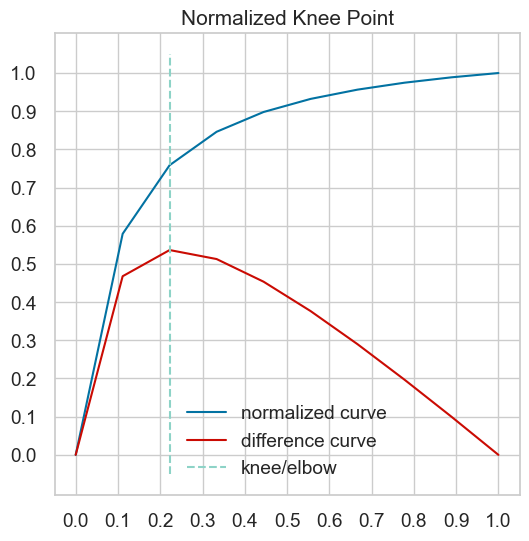

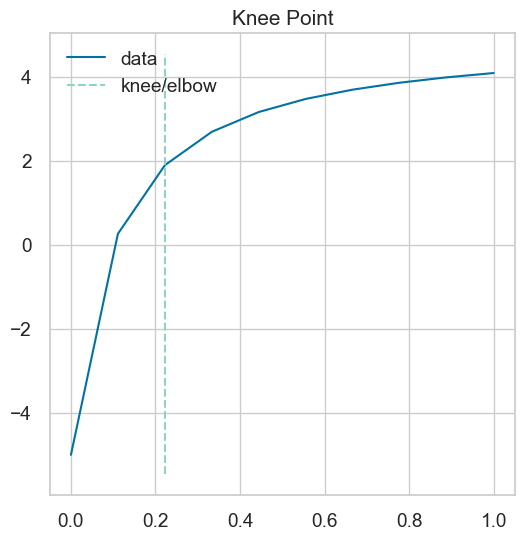

In [11]:
# Kneed sample generator & plotting

x, y = DataGenerator.figure2()

k1 = KneeLocator(x, y, curve="concave", direction="increasing")
print(k1.knee)
print(k1.knee_y)

# Alternative using find_shape to auto-detect curve type & direction
direction, curve = find_shape(x, y)
k1 = KneeLocator(x, y, curve=curve, direction=direction)

# Using kneedle.knee & kneedle.elbow to store maximum curvature points
kneedle = KneeLocator(x, y, S=1.0, curve="concave", direction="increasing")
print(round(kneedle.knee, 3))
print(round(kneedle.elbow, 3))

# Identifying the y value at the knee
print(round(kneedle.knee_y, 3))

# Normalized data, normalized knee, & normalized distance curve
kneedle.plot_knee_normalized()

# Raw data and knee
kneedle.plot_knee()

  k= 2  →  inertia = 701,020
  k= 3  →  inertia = 638,087
  k= 4  →  inertia = 582,159
  k= 5  →  inertia = 532,071
  k= 6  →  inertia = 492,068
  k= 7  →  inertia = 469,917
  k= 8  →  inertia = 452,221
  k= 9  →  inertia = 442,860
  k=10  →  inertia = 435,532
  k=11  →  inertia = 426,274
  k=12  →  inertia = 420,010
Inertia Score:
701019.5662503554
638087.4400677595
582159.3229087899
532071.4593609464
492067.6821020061
469916.73783774965
452220.7237645071
442860.41936397005
435532.329761274
426273.73163136333
420010.37835354556
KneeLocator Elbow Point: 6


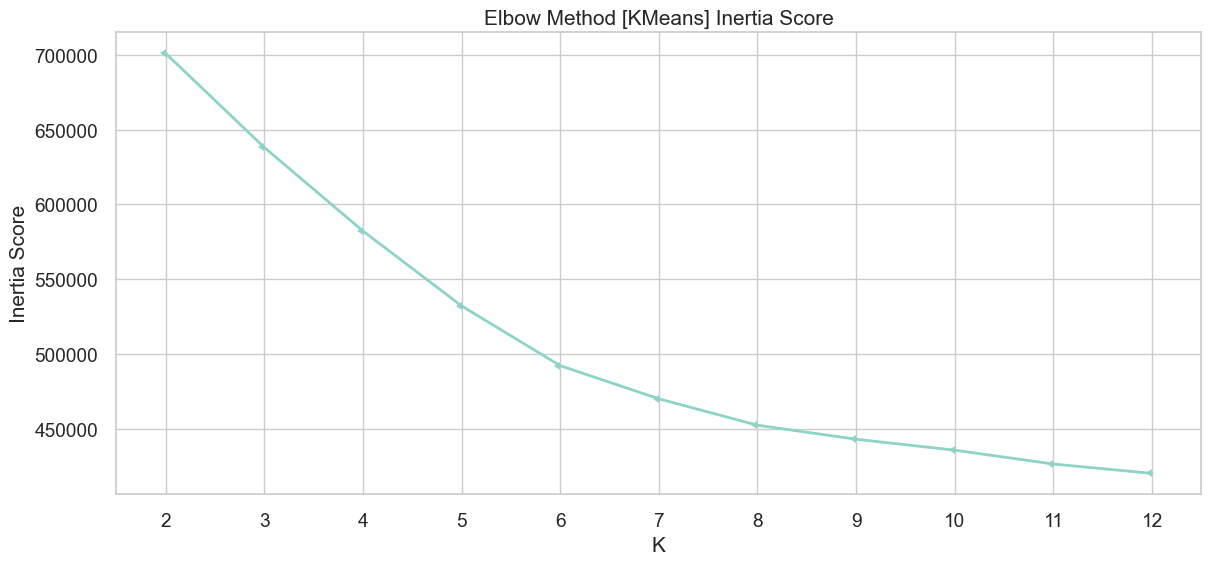

In [ ]:
# Inertia score will be stored in this list
inertia_score = []

# Defining cluster values to test
# KMeans model testing 2-12 clusters
k_values = range(2, 13)

# Iterating for loop of cluster possibilities
for k in k_values:
    # Creating initial KMeans model with max # of clusters
    kmeans = KMeans(
        n_clusters=k, 
        random_state=42, 
        n_init=12
        )

    # Fitting model on training feature matrix
    kmeans.fit(X_train)

    # Beginning intertia score (how compact clusters are)
    inertia_score.append(kmeans.inertia_)
    print(f"  k={k:2d}  →  inertia = {kmeans.inertia_:,.0f}")

print("Inertia Score:")
list(map(print, inertia_score))

# Using KneeLocator as backup to identify elbow point of the curve programmatically
k1 = KneeLocator(range(2, 13), inertia_score, curve="convex", direction="decreasing")
k1.elbow
print("KneeLocator Elbow Point:", k1.elbow)

plt.figure(figsize=(14,6))

plt.plot(range(2, 13), inertia_score, linewidth=2, marker=8)
plt.title("Elbow Method [KMeans] Inertia Score")
plt.xlabel("K")
plt.ylabel("Inertia Score")
plt.xticks(range(2, 13))
plt.show()

# saving plot as image in docs folder
# plt.savefig("C:\\Users\\winni\\music-rec-algo\\Doc\\elbow_inertia.png", dpi=150)

  k= 2  →  inertia = 420,010
  k= 3  →  inertia = 420,010
  k= 4  →  inertia = 420,010
  k= 5  →  inertia = 420,010
  k= 6  →  inertia = 420,010
  k= 7  →  inertia = 420,010
  k= 8  →  inertia = 420,010
  k= 9  →  inertia = 420,010
  k=10  →  inertia = 420,010
  k=11  →  inertia = 420,010
  k=12  →  inertia = 420,010


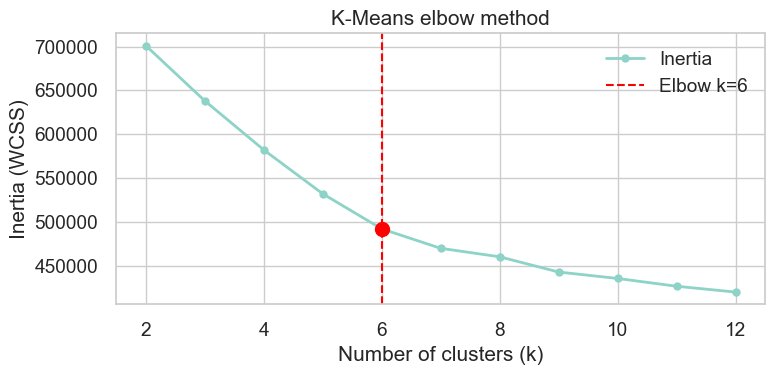

In [ ]:
# Based on the inertia scores & KneeLocator elbow point, retraining and visualizing elbow method result

# --- Elbow method ---
K_RANGE = range(2, 13)
inertias = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train)          # X_train = numeric feature matrix
    inertias.append(km.inertia_)
    print(f"  k={k:2d}  →  inertia = {kmeans.inertia_:,.0f}")

kl = KneeLocator(list(K_RANGE), inertias, curve="convex", direction="decreasing")
optimal_k = kl.elbow  # → 4
print("Optimal K:", optimal_k)

# --- Retrain final model ---
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_final.fit(X_train)
labels = kmeans_final.labels_
print(labels)

# --- Elbow plot ---
plt.figure(figsize=(8, 4))
plt.plot(list(K_RANGE), inertias, marker="o", linewidth=2, label="Inertia")
plt.axvline(x=optimal_k, color="red", linestyle="--", label=f"Elbow k={optimal_k}")
plt.scatter([optimal_k], [inertias[optimal_k - 2]], color="red", zorder=5, s=100)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.title("K-Means elbow method")
plt.legend()
plt.tight_layout()
plt.savefig("C:\\Users\\winni\\music-rec-algo\\Doc\\elbow_plot_ok.png", dpi=150)
plt.show()

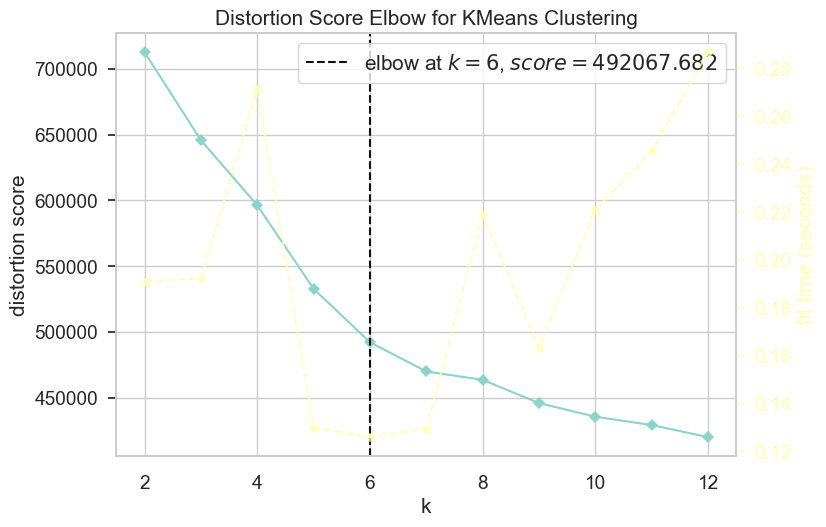

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
# Elbow Visualizer
km = KMeans(random_state=42)
visualizer = KElbowVisualizer(km, k=(2, 13))

visualizer.fit(X_train)
visualizer.show()
plt.savefig("C:\\Users\\winni\\music-rec-algo\\Doc\\distort_elbow_plt.png", dpi=150)

[2 5 6 ... 3 3 3]


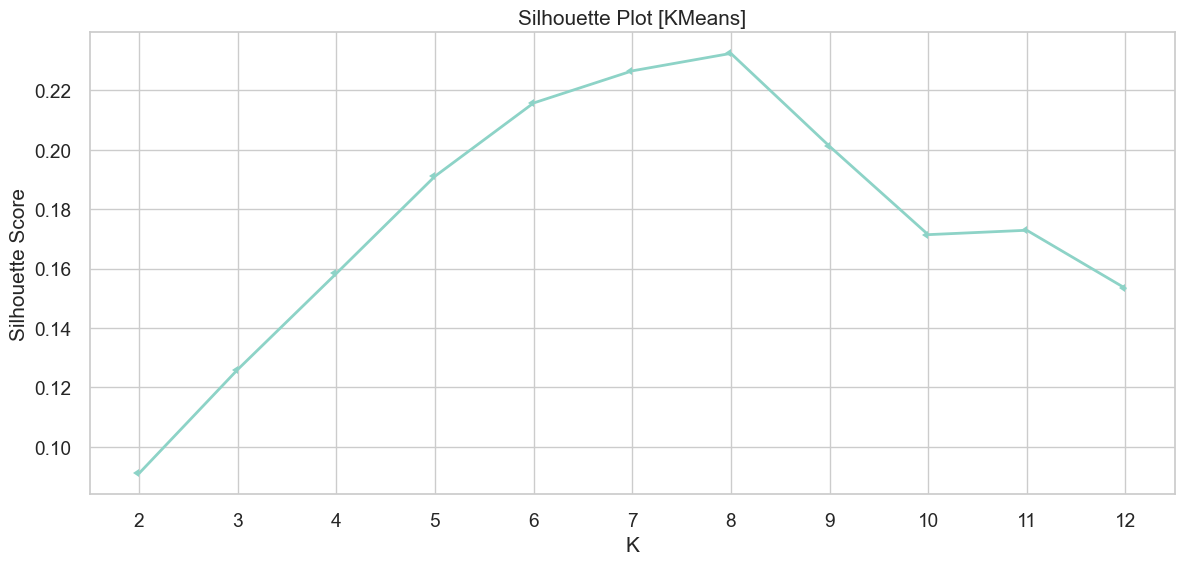

In [23]:
# Silhouette score will be stored in this list
silhouette = []

# Iterating for loop of cluster possibilities
for k in range(2, 13):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=12)

    predictions = kmeans.fit_predict(X_train.values)
    silhouette.append(silhouette_score(X_train, predictions))
    #print(f"  k={k:2d}  →  silhouette = {predictions,.0f}")
cluster_labels = kmeans.labels_
print(cluster_labels)

plt.figure(figsize=(14, 6))

plt.plot(range(2, 13), silhouette, linewidth=2, marker=8)
plt.title("Silhouette Plot [KMeans]")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.show()

# saving plot as image in docs folder
# plt.savefig("C:\\Users\\winni\\music-rec-algo\\FOLDER")

Silhouette Score for KMeans with k = 12 : 0.172647717127423


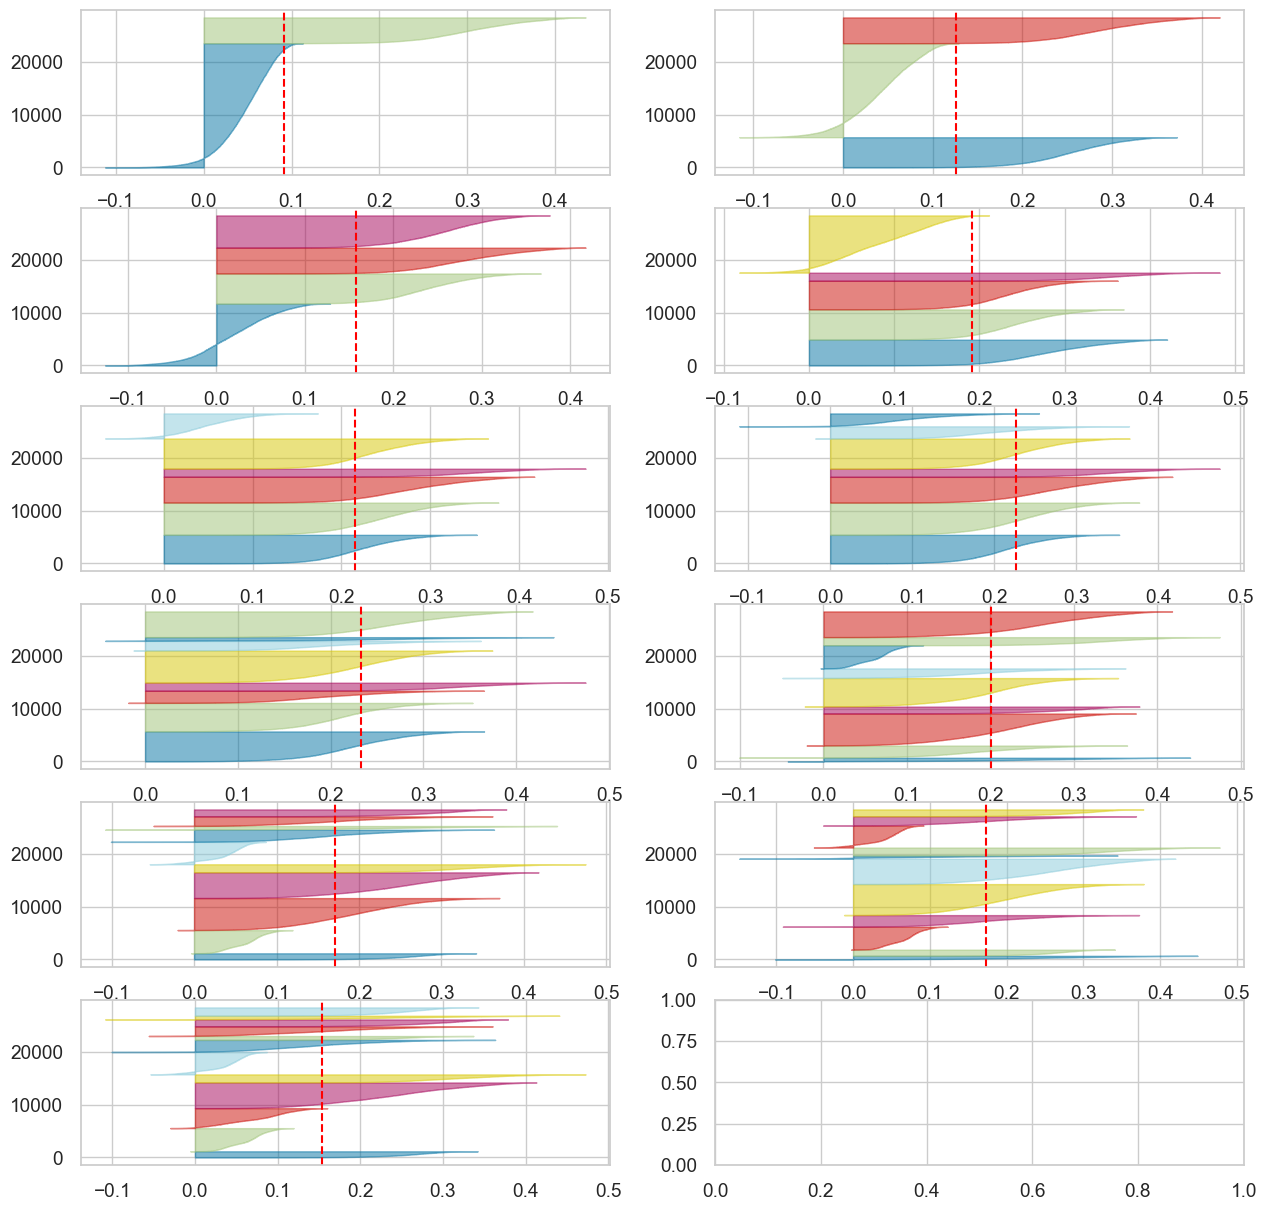

In [ ]:
# Crosschecking Elbow Visualizer recommendation with silhouette score
k_values = range(2, 13)

for k in k_values:
    model = KMeans(k)
    model.fit(X_train)
    # Prediction of models
    Pred = model.predict(X_train)

print("Silhouette Score for KMeans with k =", k, ":", silhouette_score(X_train, Pred))

# Plotting silhouette score for each cluster

fig, ax = plt.subplots(6, 2, figsize=(20, 20))    # 6 rows to fit k=2..12 (11 plots)

for i, k in enumerate(k_values):
    # Creat KMeans instances for different number of clusters
    km = KMeans(n_clusters=k, init='k-means++', n_init=12, max_iter=100, random_state=42)
    row, col = divmod(i, 2)    # Using enumerate index, not k itself
    # Create SilhouetteVisualizer instance with the KMeans & fit it
    visualizer = SilhouetteVisualizer(km, colors='yellowbrick', ax=ax[row][col])
    visualizer.fit(X_train)
plt.savefig("C:\\Users\\winni\\music-rec-algo\\Doc\\silhouette_cluster_viz.png", dpi=150)

[2 5 6 ... 3 3 3]


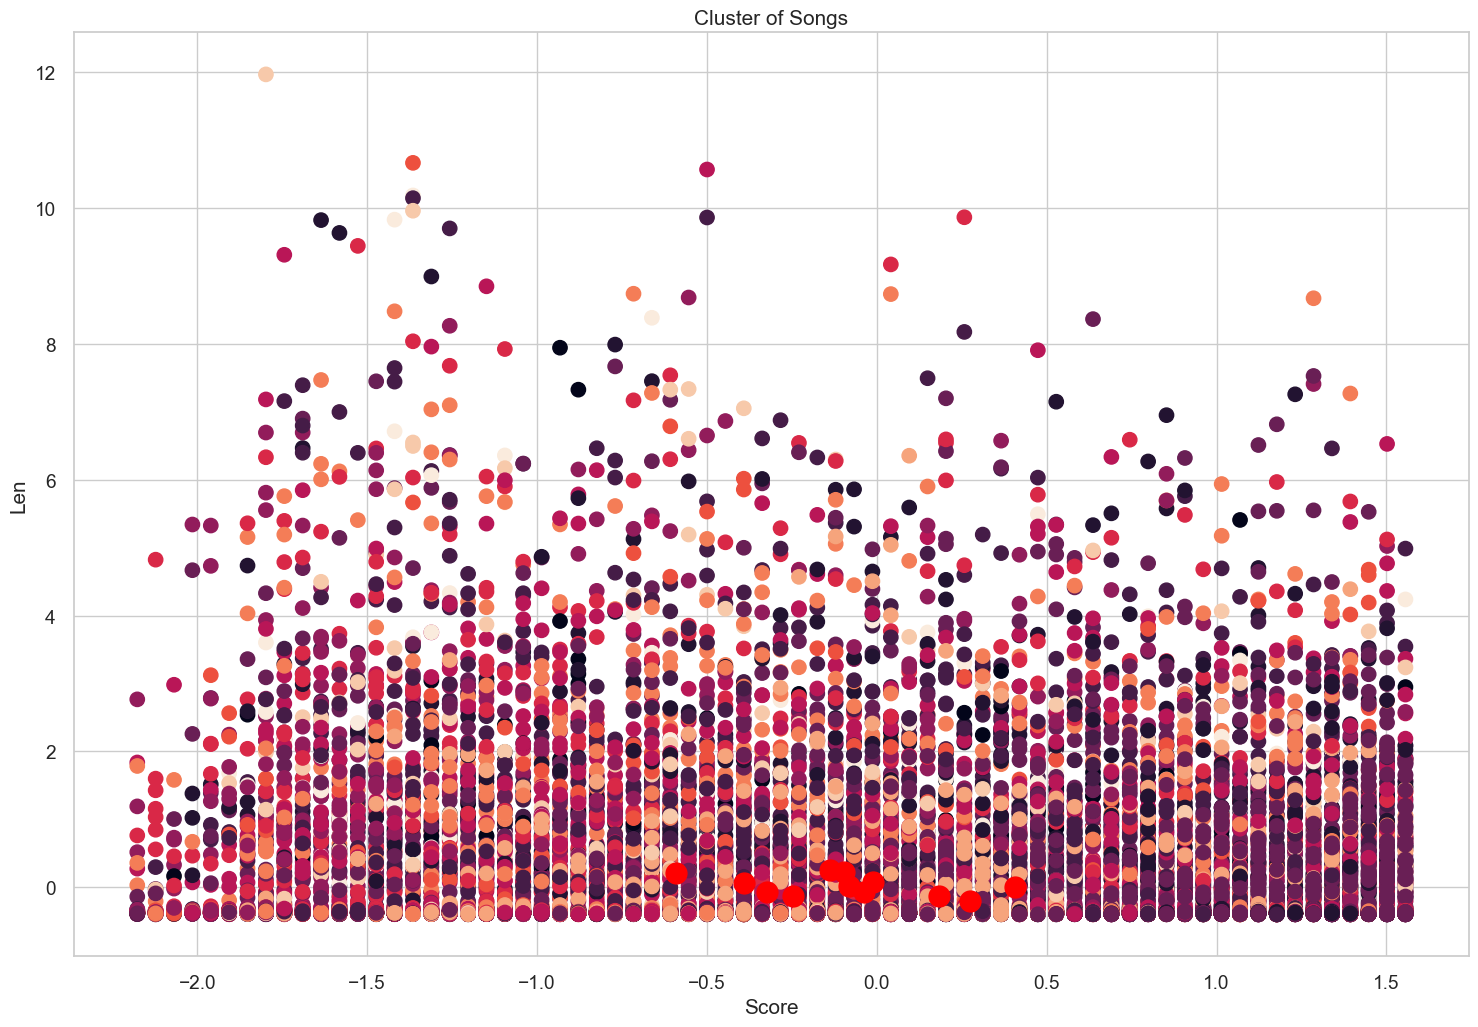

In [ ]:
# Creating 2D cluster visual Elbow/Silhouette to help finalize decision

labels = kmeans.fit_predict(X_train.values)
print(labels)

kmeans.cluster_centers_

# Convert X_train to NumPy array for indexing
X_train_array = X_train.values

plt.figure(figsize=(18, 12))

plt.scatter(X_train_array[:, 0], X_train_array[:, 1], c=kmeans.labels_, s=106)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], color='red', s=225)
plt.title("Cluster of Songs")
plt.xlabel("Score")
plt.ylabel("Len")
plt.show()

# plt.savefig("C:\\Users\\winni\\music-rec-algo\\Doc\\cluster_o_songs.png", dpi=150)

##### *Elbow & Silhouette Insights*

abc

##### **<p style="text-align:center;">3B. Choosing Clusters</p>**    
Performing encoding separately to minimize chance of error.

In [ ]:
# Label 


In [ ]:
# Drop


In [ ]:
# Strong positive


---
### **4. Modeling Music Features**

In [ ]:
# Model test ... apply KMeans to music

# result should be songs

In [ ]:
# Grouping rating columns together to represent music track attributes
rating = ['dating', 'family_gospel', 'communication', 'family_spiritual', 'like_girls', 
          'shake_the_audience', 'movement_places', 'light_visual_perceptions']

X = songs['rating']

# Apply KMeans clustering with k=3 on selected features
kmeans_music = kmeans(n_clusters=3, random_state=42)
kmeans_music.fit(X)

# Box plot of rating columns
plt.figure(figsize=(12, 6))
sns.boxplot(data=df['rating'], orient='h', palette='spectral')
plt.title('Box Plot of Rating Columns')
plt.xlabel('Rating Score')
plt.ylabel('Columns')
plt.show()

In [ ]:
# Using sample of 10 unlabeled songs to see number of cluster generation
sample_songs = songs.sample(10)

selected_predictors = sample_songs[rating]
sample_labels = kmeans_music.predict(selected_predictors)

# sample_songs[pred] = sample_labels

In [ ]:
# Handling outliers with IQR capping at 1.5*IQR boundary (Winsorization)
# Done in lieu of dropping rows, thereby preserving data

for col in skewed_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df1_log_t[col] = df1_log_t[col].clip(lower=lower, upper=upper)

# Using log1p again to handle zero values safely
# Only appling it to positively skewed columns (skew > 0.5)
for col in skewed_cols:
    if skewness[col] > 0.5:
        df1_log_t[col] = np.log1p(df1_log_t[col])
    elif skewness[col] < -0.5:
        # Reflect then log for negatively skewed
        df1_log_t[col] = np.log1p(df1_log_t[col].max() - df1_log_t[col])

In [ ]:
# Checking for any missing values after skew & transformations
print(df1_log_t.isnull().sum())

# For numeric columns, fill with median (robust to outliers)
num_cols = df1_log_t.select_dtypes(include='number').columns
df1_log_t[num_cols] = df1_log_t[num_cols].fillna(df1_log_t[num_cols].median())

# For categorical columns, fill with mode
cat_cols = df1_log_t.select_dtypes(include='object').columns
for col in cat_cols:
    df1_log_t[col] = df1_log_t[col].fillna(df1[col].mode()[0])

In [ ]:
# Scaling columns
cols_to_scale = df1_log_t.select_dtypes(include=['int', 'float']).columns.tolist()
scaler = StandardScaler()

df1_scaled = df1_log_t.copy()
df1_scaled[cols_to_scale] = scaler.fit_transform(df1_log_t[cols_to_scale])

print(df1_scaled.head(5))

---
### **5. Verifying Changes**

In [ ]:
# Confirm no missing values remain
print("Missing values after cleaning:")
print(df1_scaled.isnull().sum())
print()

# Confirm shape is intact
print("DataFrame shape:\n", df1_scaled.shape)

# Numeric columns check
print("\nNumeric column stats:")
print(df1_scaled[num_cols].describe())

---
### **6. Save Cleaned CSV**

In [ ]:
# Explicity noting path as being in Windows format so I can use forward slash
clean = PureWindowsPath("C:\\Users\\Winni\\music-rec-algo\\Data\\cleaned.csv")

# Convert path to the correct format
file_path = Path(clean)

# Saving data as a DataFrame
df1_scaled.to_csv(file_path, index=False)
# index=False prevents pandas from saving row numbers as a column
print("Cleaned data saved successfully!")

In [ ]:
# Most reliable confirmation is to reload saved file and review it
clean = PureWindowsPath("C:\\Users\\Winni\\music-rec-algo\\Data\\cleaned.csv")
file_path = Path(clean)

df1_clean = pd.read_csv(file_path)

print("Shape:", df1_clean.shape)
print("Missing values:\n", df1_clean.isnull().sum())
print("\nFinal columns:", df1_clean.columns.tolist())
print("\nPreview:\n", df1_clean.head(5))